## Bike Store Project (SQL, Python)

### Overview

We are given a sample bike store dataset consisting of tables such as `categories` `customers` `orders` `products`. 

### Objectives

This project aims to demonstrate fluency in SQL and python libraries such as pandas and matplotlib in the context of business analytics.

### Sample schema diagram

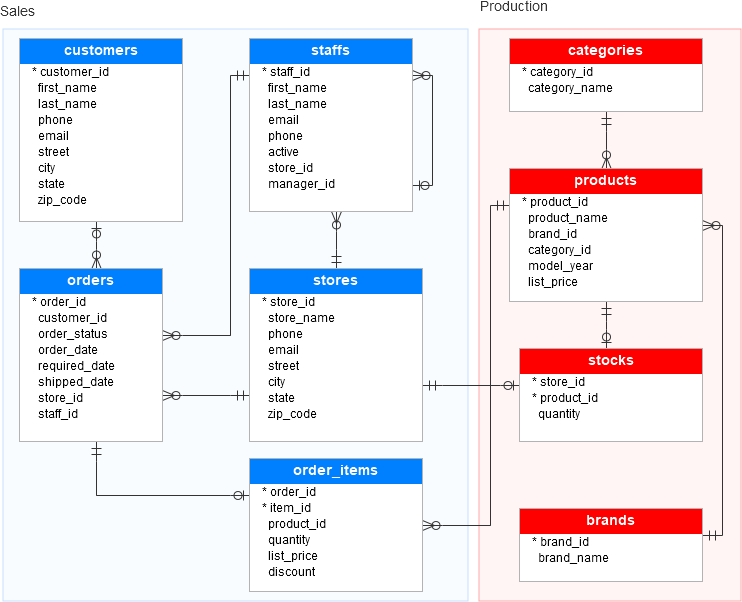

### Notes

To simulate a large fictional database, we load all csv datasets into a sqlite database and use pandas to read sql queries into dataframes. 

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Read in CSV files
brands = pd.read_csv('input/bike-store-sample-database/brands.csv')
categories = pd.read_csv('input/bike-store-sample-database/categories.csv')
customers = pd.read_csv('input/bike-store-sample-database/customers.csv')
order_items = pd.read_csv('input/bike-store-sample-database/order_items.csv')
orders = pd.read_csv('input/bike-store-sample-database/orders.csv')
products = pd.read_csv('input/bike-store-sample-database/products.csv')
staffs = pd.read_csv('input/bike-store-sample-database/staffs.csv')
stocks = pd.read_csv('input/bike-store-sample-database/stocks.csv')
stores = pd.read_csv('input/bike-store-sample-database/stores.csv')

# Create database connection
connection = sqlite3.connect('bike_store.db')

# Insert data into database
brands.to_sql('brands', connection, if_exists='replace', index=False)
categories.to_sql('categories', connection, if_exists='replace', index=False)
customers.to_sql('customers', connection, if_exists='replace', index=False)
order_items.to_sql('order_items', connection, if_exists='replace', index=False)
orders.to_sql('orders', connection, if_exists='replace', index=False)
products.to_sql('products', connection, if_exists='replace', index=False)
staffs.to_sql('staffs', connection, if_exists='replace', index=False)
stocks.to_sql('stocks', connection, if_exists='replace', index=False)
stores.to_sql('stores', connection, if_exists='replace', index=False)

3

When exploring a dataset, my workflow consists of the following steps:
- Pick a small enough table
- Extract the first 10 rows to get a feel of the contents
- Ask insightful questions about the given dataset

## Exploring the dataset

Let's start from the smaller tables and work our way up. For starters, let's look at `brands`, `categories`

First 10 rows

In [72]:
query = """
SELECT *
FROM brands;
"""
pd.read_sql_query(query, connection)

,brand_id,brand_name
0,1,Electra
1,2,Haro
2,3,Heller
3,4,Pure Cycles
4,5,Ritchey
5,6,Strider
6,7,Sun Bicycles
7,8,Surly
8,9,Trek


In [73]:
query = """
SELECT *
FROM categories;
"""
pd.read_sql_query(query, connection)

,category_id,category_name
0,1,Children Bicycles
1,2,Comfort Bicycles
2,3,Cruisers Bicycles
3,4,Cyclocross Bicycles
4,5,Electric Bikes
5,6,Mountain Bikes
6,7,Road Bikes


**Observations**  

Alright, we have a handful of bike categories and brands. Various bike categories may cater to different customer groups such as adults or children while various bike brands may have different prices and quality.

With the big picture in mind, let's look at `products` for more details.

In [77]:
query = """
SELECT *
FROM products;
"""
pd.read_sql_query(query, connection)

,product_id,product_name,brand_id,category_id,model_year,list_price
0,1,Trek 820 - 2016,9,6,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99
...,...,...,...,...,...,...
316,317,Trek Checkpoint ALR 5 - 2019,9,7,2019,1999.99
317,318,Trek Checkpoint ALR 5 Women's - 2019,9,7,2019,1999.99
318,319,Trek Checkpoint SL 5 Women's - 2019,9,7,2019,2799.99
319,320,Trek Checkpoint SL 6 - 2019,9,7,2019,3799.99


**Observations**  

We have around 300 products. Notably, each product have a `model_year` and `list_price`, which can change over time. The significance of `model_year` is not obvious at this tage but we can expect newer models to have higher prices. 

**Questions**

- What is the cheapest/most expensive product?

In [83]:
query = """
SELECT MAX(list_price) as max_price, MIN(list_price) as min_price, AVG(list_price) as avg_price
FROM products
ORDER BY list_price DESC;
"""
pd.read_sql_query(query, connection)

,max_price,min_price,avg_price
0,11999.99,89.99,1520.591402


**Observations**  

The price distribution seems quite large even though all products are bikes. We can take note of that.

Now, let's move on to look at the sales side of things. The most interesting tables are `customers`, `orders` and `order_items`. 

First 10 rows

In [74]:
query = """
SELECT *
FROM customers;
"""
pd.read_sql_query(query, connection)

,customer_id,first_name,last_name,phone,email,street,city,state,zip_code
0,1,Debra,Burks,NaN,debra.burks@yahoo.com,9273 Thorne Ave.,Orchard Park,NY,14127
1,2,Kasha,Todd,NaN,kasha.todd@yahoo.com,910 Vine Street,Campbell,CA,95008
2,3,Tameka,Fisher,NaN,tameka.fisher@aol.com,769C Honey Creek St.,Redondo Beach,CA,90278
3,4,Daryl,Spence,NaN,daryl.spence@aol.com,988 Pearl Lane,Uniondale,NY,11553
4,5,Charolette,Rice,(916) 381-6003,charolette.rice@msn.com,107 River Dr.,Sacramento,CA,95820
...,...,...,...,...,...,...,...,...,...
1440,1441,Jamaal,Morrison,NaN,jamaal.morrison@msn.com,796 SE. Nut Swamp St.,Staten Island,NY,10301
1441,1442,Cassie,Cline,NaN,cassie.cline@gmail.com,947 Lafayette Drive,Brooklyn,NY,11201
1442,1443,Lezlie,Lamb,NaN,lezlie.lamb@gmail.com,401 Brandywine Street,Central Islip,NY,11722
1443,1444,Ivette,Estes,NaN,ivette.estes@gmail.com,88 N. Canterbury Ave.,Canandaigua,NY,14424


**Observations**  
The customer table provides the personal particulars of the customer as expected. We can see that some columns such as phone number have missing data. Interestingly, we have the geographical information of the customer's home address.

In [75]:
query = """
SELECT *
FROM orders;
"""
pd.read_sql_query(query, connection)

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6
...,...,...,...,...,...,...,...,...
1610,1611,6,3,2018-09-06,2018-09-06,NaN,2,7
1611,1612,3,3,2018-10-21,2018-10-21,NaN,1,3
1612,1613,1,3,2018-11-18,2018-11-18,NaN,2,6
1613,1614,135,3,2018-11-28,2018-11-28,NaN,3,8


**Observations**  
We can see that `orders` provide timestamp data to tell us when the order was placed and when it was shipped. `required_date` can mean a few things. We can make a smart guess that it refers to a kind of shipping deadline for that order. `order_status` seems to be a categorical variable indexed using an `int` which is curious.

In [76]:
query = """
SELECT *
FROM order_items;
"""
pd.read_sql_query(query, connection)

,order_id,item_id,product_id,quantity,list_price,discount
0,1,1,20,1,599.99,0.20
1,1,2,8,2,1799.99,0.07
2,1,3,10,2,1549.00,0.05
3,1,4,16,2,599.99,0.05
4,1,5,4,1,2899.99,0.20
...,...,...,...,...,...,...
4717,1614,2,159,2,2299.99,0.07
4718,1614,3,213,2,269.99,0.20
4719,1615,1,197,2,2299.99,0.20
4720,1615,2,214,1,899.99,0.07


**Observations**  
We may note that discount(s) may be given for an order so the profit should be calcualated accordingly. An order may consist of one or more products. `list_price` may refer to the price of one pcs of the product at the time of sale, i.e. when the order was placed.

## Understanding the data

We can use visuals to understand and present insights about the data to stakeholders.

**Products by category**  

Let's try to understand how products is distributed by category. A pie chart may be useful here. We might join the `product` and `category` table(s).

Questions may include:
- Which category has the most products?
- What are the top 10 categories by number of products?

<Axes: title={'center': 'Product count by category'}>

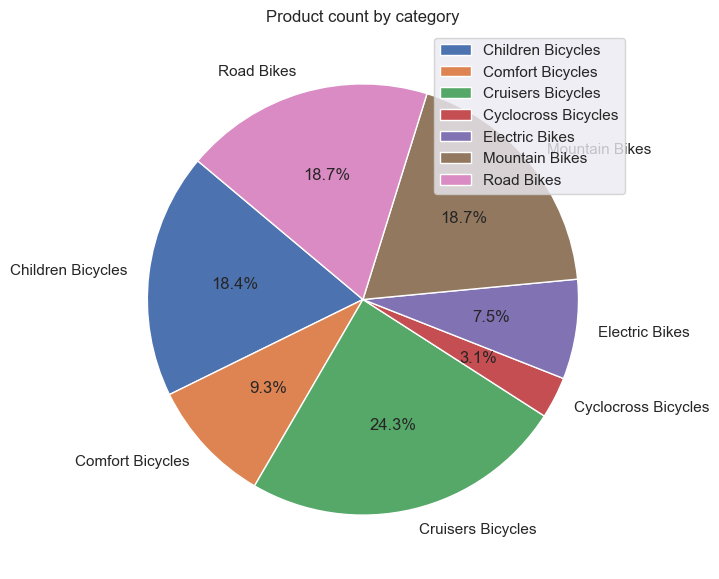

In [125]:
query = """
SELECT COUNT(*) as product_count, category_name
FROM products p
INNER JOIN categories c ON p.category_id = c.category_id
GROUP BY category_name;
"""

df = pd.read_sql_query(query, connection)
df.plot.pie(title='Product count by category', y='product_count', labels=df['category_name'], autopct='%1.1f%%', startangle=140, figsize=(7, 7))

## Revenue by category

To complemenet the category by product-count view, we can look at revenue by category to get a more complete picture of the significance of categories since products have varying prices. To do this, we can join the table `order_items` on top of `products` and `categories`. We also note that price is calculated with `discount` in mind. For each order item, there is a `discount` and `list_price`. We should use `list_price` in `order_items` as ground truth since `list_price` can potentially change over time in `products`.

Before that, we can find the total revenue before and after discount as such:

In [120]:
query = """
SELECT COUNT(*) as product_count, SUM(oi.quantity * oi.list_price * (1 - oi.discount)) as revenue_before_discount, SUM(oi.quantity * oi.list_price) as revenue_after_discount
FROM order_items oi
INNER JOIN products p ON oi.product_id = p.product_id;
"""
pd.read_sql_query(query, connection)

,product_count,revenue_before_discount,revenue_after_discount
0,4722,7.689117e+06,8578988.88


Then, simply join with `categories` and group by `catogories_id` or `categories_name`

<Axes: title={'center': 'Revenue by category'}>

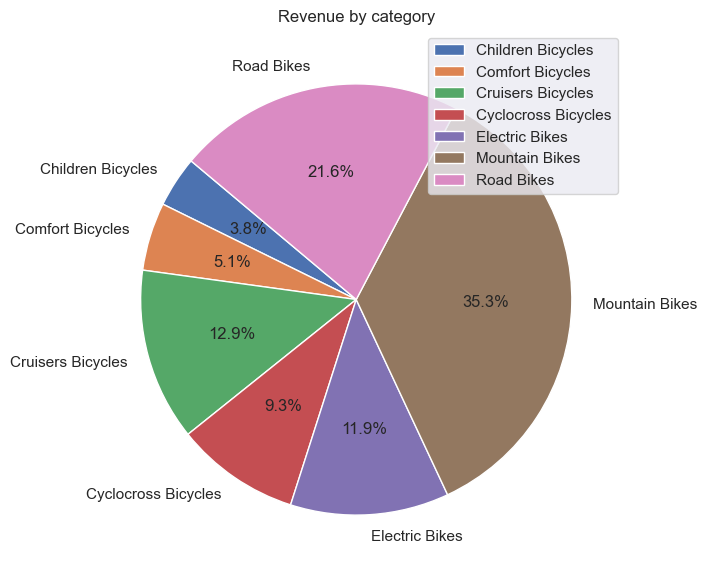

In [157]:
query = """
SELECT category_name, COUNT(*) as product_count, SUM(oi.quantity * oi.list_price * (1 - oi.discount)) as revenue_before_discount, SUM(oi.quantity * oi.list_price) as revenue_after_discount
FROM order_items oi
INNER JOIN products p ON oi.product_id = p.product_id
INNER JOIN categories c ON p.category_id = c.category_id
GROUP BY category_name;
"""
df = pd.read_sql_query(query, connection)
df.plot.pie(title='Revenue by category', y='revenue_after_discount', labels=df['category_name'], autopct='%1.1f%%', startangle=140, figsize=(7, 7))

**Observations**  
There are more Cruiser Bicycles than Mountain Bikes. However, Mountain Bikes tend to be more expensive and tops revenue by category. Let's analyze the distribution of bike prices by category at a finer level. We can use a box plot to do univariate data analysis and understand the variable's distribution.

<Axes: xlabel='list_price', ylabel='category_name'>

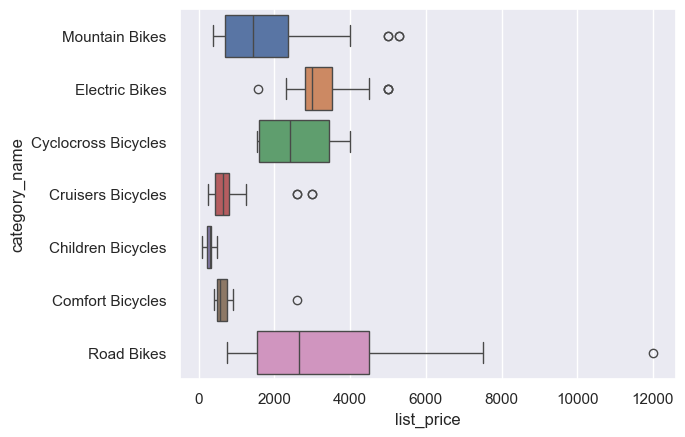

In [175]:
query = """
SELECT *
FROM products p
INNER JOIN categories c ON p.category_id = c.category_id
"""
df = pd.read_sql_query(query, connection)
sns.boxplot(data=df, x='list_price', y='category_name', hue='category_name')

## More data exploring
Now, let's look at things from a time persepective. We want to know how many years' worth of data we have. A good place to start is with `orders` since it contains information about the date/time at which an order was placed. For starters, let's sort the orders by `order_date` to understand the timeframe of the dataset. We can also count the number of distinct `order_date`

In [234]:
query = """
SELECT *
FROM orders
ORDER BY order_date DESC
LIMIT 5;
"""
pd.read_sql_query(query, connection)

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1615,136,3,2018-12-28,2018-12-28,None,3,8
1,1614,135,3,2018-11-28,2018-11-28,None,3,8
2,1613,1,3,2018-11-18,2018-11-18,None,2,6
3,1612,3,3,2018-10-21,2018-10-21,None,1,3
4,1611,6,3,2018-09-06,2018-09-06,None,2,7


In [235]:
query = """
SELECT *
FROM orders
ORDER BY order_date ASC
LIMIT 5;
"""
pd.read_sql_query(query, connection)

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6


In [249]:
query = """
SELECT COUNT(DISTINCT order_date) as order_count
FROM orders;
"""
pd.read_sql_query(query, connection)

,order_count
0,725


**Observations**  

The timeframe of this dataset spans two years, from 2016 to 2018. In particular, there are around 725 days, at least for the timeframe of `order_date`. Let's dig deeper by analyzing the orders in a time series manner.

A simple plot of cumulative sum should do the job here.

<Axes: title={'center': 'Number of orders over time'}, xlabel='order_date'>

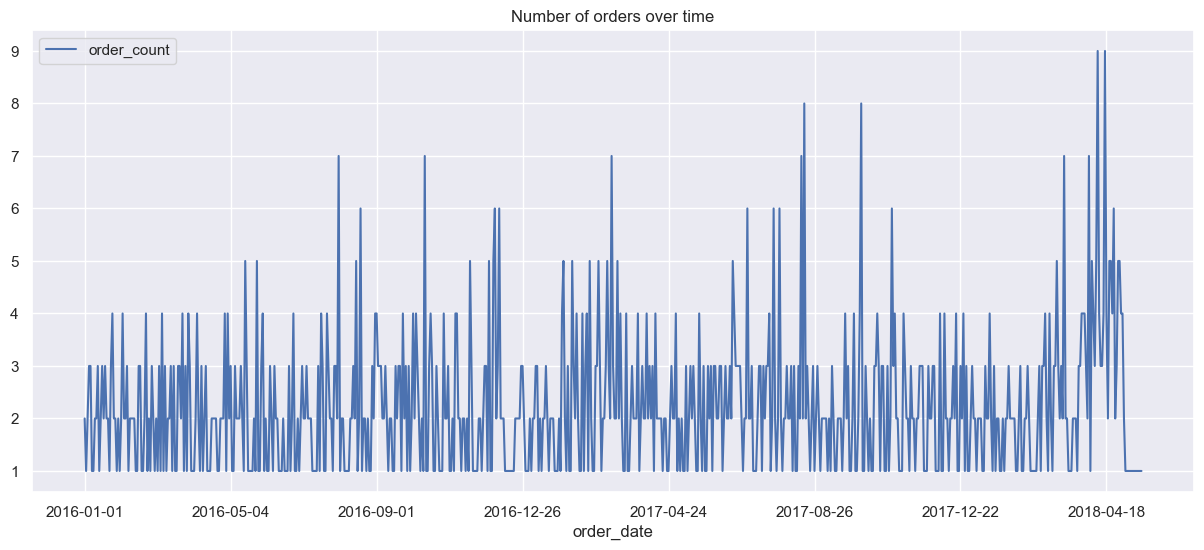

In [275]:
query = """
SELECT COUNT(*) as order_count, order_date
FROM orders
GROUP BY order_date;
"""
df = pd.read_sql_query(query, connection)
df.plot(x='order_date', y='order_count', title='Number of orders over time', figsize=(15, 6))

Wow. That is a lot to take in. The data might not be useful in this raw form. Let's break it down by looking at a smaller timeframe, such as within a specified year. We can do that by specifying the `order_date`, and using cumulative sum since we are actually interested in the running sum of number of orders.

<Axes: title={'center': 'Cumulative number of orders in 2016'}, xlabel='order_date'>

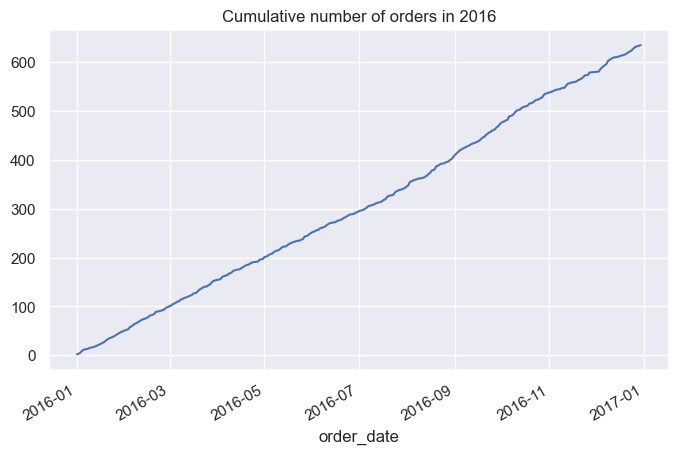

In [270]:
query = """
SELECT COUNT(*) as order_count, order_date
FROM orders
WHERE order_date >= '2016-01-01' AND order_date < '2017-01-01'
GROUP BY order_date;
"""
df = pd.read_sql_query(query, connection)
ts = pd.Series(df['order_count'].values, index=pd.to_datetime(df['order_date']))
ts = ts.cumsum()
ts.plot(title='Cumulative number of orders in 2016', figsize=(8, 5))

Alternatively, the full timeframe is shown below.

<Axes: title={'center': 'Cumulative number of orders'}, xlabel='order_date'>

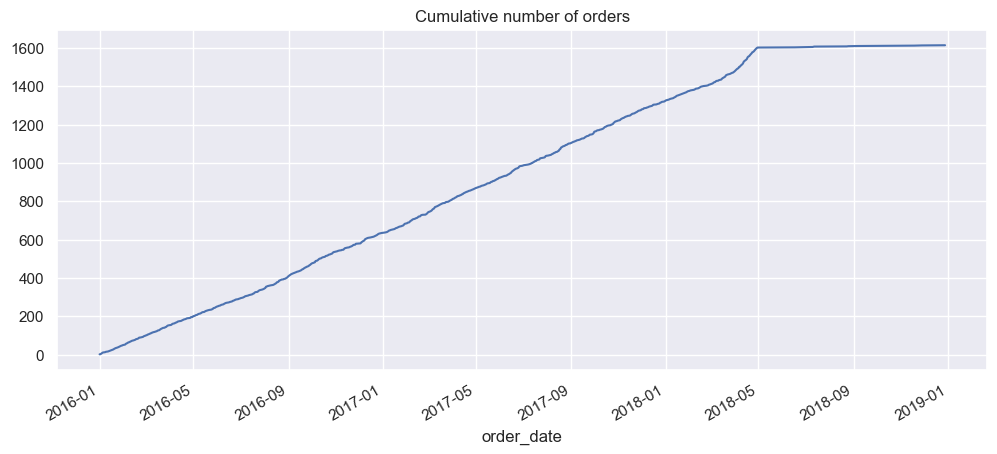

In [278]:
query = """
SELECT COUNT(*) as order_count, order_date
FROM orders
GROUP BY order_date;
"""
df = pd.read_sql_query(query, connection)
ts = pd.Series(df['order_count'].values, index=pd.to_datetime(df['order_date']))
ts = ts.cumsum()
ts.plot(title='Cumulative number of orders', figsize=(12, 5))

Much better! Now we can see a linear trend in the number of orders in 2016 through 2018. 

## Practical Examples

**Customer Segmentation**  

Query to segment customers based on recency, frequency and buying power, i.e. order count, total spent, and recency. (Note: use 2018-05 as the delimiter for recency)

In [283]:
query = """
WITH customer_stats AS (
    SELECT
        customer_id,
        SUM(quantity * list_price * (1 - discount)) AS total_spent,
        COUNT(DISTINCT orders.order_id) AS total_orders,
        julianday('2018-05-01') - julianday(MAX(order_date)) AS days_since_last_purchase
    FROM
        orders
    INNER JOIN
        order_items
    ON
        orders.order_id = order_items.order_id
    GROUP BY
        1
)

SELECT
    customer_id,
    CASE WHEN total_orders > 1 THEN 'repeat buyer'
         ELSE 'one-time buyer'
         END AS purchase_frequency,
    CASE WHEN days_since_last_purchase < 90 THEN 'recent buyer'
         ELSE 'not recent buyer'
         END AS purchase_recency,
    CASE WHEN total_spent/(SELECT MAX(total_spent) FROM customer_stats) >= .65 THEN 'big spender'
         WHEN total_spent/(SELECT MAX(total_spent) FROM customer_stats) <= .30 THEN 'low spender'
         ELSE 'average spender' 
         END AS buying_power
FROM
    customer_stats
"""

df = pd.read_sql_query(query, connection)
df

,customer_id,purchase_frequency,purchase_recency,buying_power
0,1,repeat buyer,recent buyer,big spender
1,2,repeat buyer,recent buyer,average spender
2,3,repeat buyer,recent buyer,big spender
3,4,repeat buyer,recent buyer,average spender
4,5,repeat buyer,recent buyer,average spender
...,...,...,...,...
1440,1441,one-time buyer,not recent buyer,low spender
1441,1442,one-time buyer,not recent buyer,low spender
1442,1443,one-time buyer,not recent buyer,low spender
1443,1444,one-time buyer,not recent buyer,low spender


<Axes: title={'center': 'Buying Power'}>

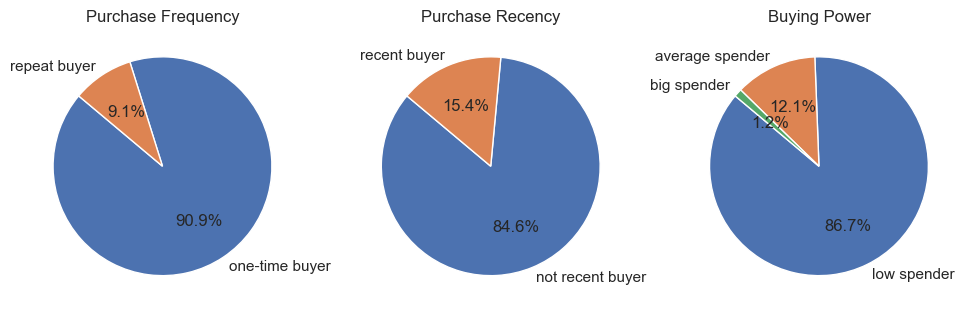

In [284]:
purchase_frequency = df['purchase_frequency'].value_counts()
purchase_recency = df['purchase_recency'].value_counts()
buying_power = df['buying_power'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(12, 8))
purchase_frequency.plot.pie(ax=axes[0], title='Purchase Frequency', autopct='%1.1f%%', startangle=140)
purchase_recency.plot.pie(ax=axes[1], title='Purchase Recency', autopct='%1.1f%%', startangle=140)
buying_power.plot.pie(ax=axes[2], title='Buying Power', autopct='%1.1f%%', startangle=140)

**Seasonality Analysis**

Query to find the average units sold for each month of the year, for each product category:

In [13]:
query = """
WITH product_categories AS (
    SELECT
        product_id,
        category_name
    FROM
        products
    INNER JOIN
        categories
    ON
        products.category_id = categories.category_id
),

product_sales_ym AS (
    SELECT
        strftime('%Y', order_date) AS year,
        strftime('%m', order_date) AS month,
        product_id,
        SUM(quantity) AS units_sold
    FROM
        orders
    INNER JOIN
        order_items
    ON
        orders.order_id = order_items.order_id
    GROUP BY
        1,2,3
)

SELECT
    month,
    category_name,
    AVG(units_sold) AS avg_units_sold
FROM
    product_sales_ym
INNER JOIN
    product_categories
ON
    product_sales_ym.product_id = product_categories.product_id
GROUP BY
    1,2;
"""

df = pd.read_sql_query(query, connection)
df

,month,category_name,avg_units_sold
0,01,Children Bicycles,2.973684
1,01,Comfort Bicycles,2.846154
2,01,Cruisers Bicycles,3.000000
3,01,Cyclocross Bicycles,3.200000
4,01,Electric Bikes,2.733333
...,...,...,...
79,12,Cruisers Bicycles,4.965517
80,12,Cyclocross Bicycles,8.600000
81,12,Electric Bikes,5.750000
82,12,Mountain Bikes,3.461538


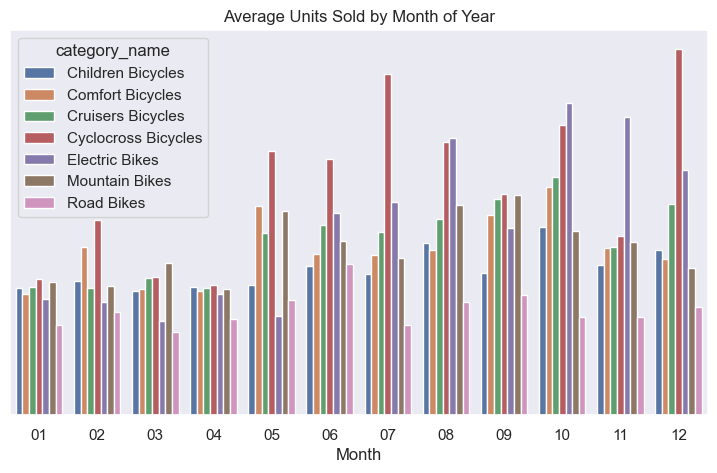

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=df, x='month', y='avg_units_sold', hue='category_name', errorbar=None, ax=ax)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('Month')
ax.set_title('Average Units Sold by Month of Year')
plt.show()

In [ ]:
# cumsumulative line plot by category


KeyError: 'avg_units_sold'

**Market Basket**  

Query to find frequently co-purchased products with a specific product:

In [7]:
query = """
SELECT
    product_a,
    product_b,
    co_purchase_count
FROM 
    (
     SELECT
         p1.product_name AS product_a,
         p2.product_name AS product_b,
         COUNT(*) AS co_purchase_count
     FROM
         order_items s1
     INNER JOIN
         order_items s2 ON s1.order_id = s2.order_id AND s1.product_id <> s2.product_id
     INNER JOIN
         products p1 ON s1.product_id = p1.product_id
     INNER JOIN
         products p2 ON s2.product_id = p2.product_id
     GROUP BY
         p1.product_id, p2.product_id
    ) subquery
ORDER BY
    co_purchase_count DESC;
"""

df = pd.read_sql_query(query, connection)
# remove duplicates (product_a, product_b) and (product_b, product_a), only choose odd rows to keep one of the pairs
df = df.iloc[::2, :]
df

,product_a,product_b,co_purchase_count
0,Heller Shagamaw Frame - 2016,Electra Girl's Hawaii 1 (16-inch) - 2015/2016,15
2,Trek Conduit+ - 2016,Surly Straggler 650b - 2016,14
4,Electra Townie Original 21D - 2016,Electra Cruiser 1 (24-Inch) - 2016,14
6,Electra Moto 1 - 2016,Electra Cruiser 1 (24-Inch) - 2016,14
8,Trek Conduit+ - 2016,Surly Straggler - 2016,13
...,...,...,...
6918,Electra Townie Original 1 Ladies' - 2018,Electra Townie Go! 8i Ladies' - 2018,1
6920,Electra Townie Original 1 Ladies' - 2018,"Electra Under-The-Sea 1 16"" - 2018",1
6922,Electra Townie Original 21D EQ Ladies' - 2018,Trek Farley Carbon Frameset - 2018,1
6924,Electra Townie Original 21D Ladies' - 2018,Trek Girl's Kickster - 2017,1


In [9]:
# Top 10 products by revenue
query = """
SELECT
    p.product_name,
    SUM(oi.quantity * oi.list_price * (1 - oi.discount)) AS revenue,
    SUM(oi.quantity) AS total_units_sold 
FROM order_items oi
INNER JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_id, p.product_name
ORDER BY revenue DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, connection)
df

,product_name,revenue,total_units_sold
0,Trek Slash 8 27.5 - 2016,555558.6111,154
1,Trek Conduit+ - 2016,389248.7025,145
2,Trek Fuel EX 8 29 - 2016,368472.7294,143
3,Surly Straggler 650b - 2016,226765.5510,151
4,Trek Domane SLR 6 Disc - 2017,211584.6153,43
5,Surly Straggler - 2016,203507.6200,147
6,Trek Remedy 29 Carbon Frameset - 2016,203380.8701,125
7,Trek Powerfly 8 FS Plus - 2017,188249.6235,41
8,Trek Madone 9.2 - 2017,175899.6482,39
9,Trek Silque SLR 8 Women's - 2017,174524.7315,29


**Customer Lifetime Value (LTV) and Average Order Value**  
Query to compute total spent, order count, and average order value per customer.

In [61]:
query = """
WITH customer_orders AS (
    SELECT
        o.customer_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.quantity * oi.list_price * (1 - oi.discount)) AS total_spent
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY o.customer_id
)
SELECT
    customer_id,
    total_orders,
    total_spent,
    CASE WHEN total_orders = 0 THEN 0 ELSE total_spent / total_orders END AS avg_order_value
FROM customer_orders
ORDER BY total_spent DESC
"""
df = pd.read_sql_query(query, connection)
df

,customer_id,total_orders,total_spent,avg_order_value
0,94,2,34807.9392,17403.969600
1,10,3,33634.2604,11211.420133
2,75,2,32803.0062,16401.503100
3,6,3,32675.0725,10891.690833
4,16,3,31925.8857,10641.961900
...,...,...,...,...
1440,177,1,170.9910,170.991000
1441,752,1,170.9910,170.991000
1442,1111,1,170.9910,170.991000
1443,718,1,167.9920,167.992000


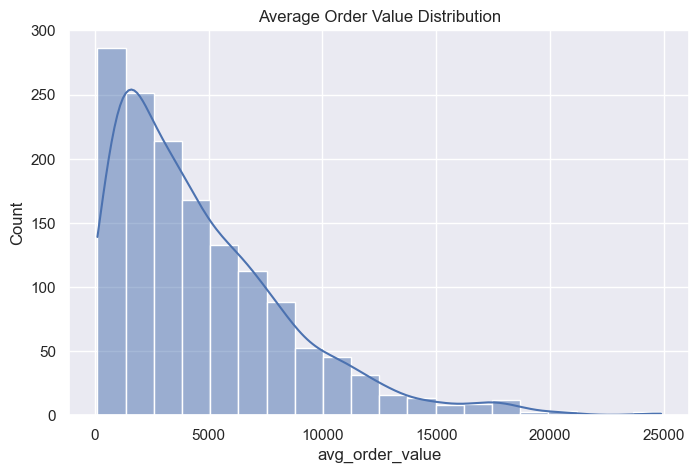

In [62]:
# Plot average order value distribution
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x='avg_order_value', bins=20, kde=True, ax=ax)
ax.set_title('Average Order Value Distribution')
plt.show()

**Expected Shipping Time by Product Category and Store**  
Estimate expected days between `order_date` and `shipped_date` per category (excludes NULL shipped dates).

In [210]:
query = """
SELECT julianday(shipped_date) - julianday(order_date) AS days_to_ship, category_name, p.product_name
FROM orders o
INNER JOIN order_items oi ON o.order_id = oi.order_id
INNER JOIN products p ON oi.product_id = p.product_id
INNER JOIN categories c ON p.category_id = c.category_id
"""
df = pd.read_sql_query(query, connection)
df

,days_to_ship,category_name,product_name
0,2.0,Mountain Bikes,Trek Fuel EX 8 29 - 2016
1,2.0,Mountain Bikes,Trek Remedy 29 Carbon Frameset - 2016
2,2.0,Cyclocross Bicycles,Surly Straggler - 2016
3,2.0,Cruisers Bicycles,Electra Townie Original 7D EQ - 2016
4,2.0,Cruisers Bicycles,Electra Townie Original 7D EQ - Women's - 2016
...,...,...,...
4717,NaN,Road Bikes,Trek Emonda ALR 6 - 2018
4718,NaN,Cruisers Bicycles,Electra Cruiser 1 - 2016/2017/2018
4719,NaN,Road Bikes,Trek Domane SL 5 Disc - 2018
4720,NaN,Electric Bikes,Trek Verve+ Lowstep - 2018


In [220]:
query = """
SELECT julianday(shipped_date) - julianday(order_date) AS days_to_ship, store_name
FROM orders o
INNER JOIN stores s ON o.store_id = s.store_id
"""
df = pd.read_sql_query(query, connection)
df

,days_to_ship,store_name
0,2.0,Santa Cruz Bikes
1,2.0,Baldwin Bikes
2,1.0,Baldwin Bikes
3,2.0,Santa Cruz Bikes
4,3.0,Baldwin Bikes
...,...,...
1610,NaN,Baldwin Bikes
1611,NaN,Santa Cruz Bikes
1612,NaN,Baldwin Bikes
1613,NaN,Rowlett Bikes


## Executive Summary

For this sample bike store dataset, we can conclude

Upon time series analysis, the number of orders grew steadily in a linear fashion till May 2018, when orders stopped coming in.

Upon cohort analysis, the customers are mostly one-time buyers with weak purchasing power. This might makes sense for a bike shop where the average person commits to just one bike.